==== 基本統計 ====


,count,mean,std,min,25%,50%,75%,max,Skew,Kurtosis,JB_pvalue
Ticker,,,,,,,,,,,
AAPL,2514.0,0.000930,0.017934,-0.137708,-0.007355,0.001000,0.010093,0.113158,-0.201228,5.457399,0.0
NVDA,2514.0,0.002248,0.030378,-0.207712,-0.012514,0.002648,0.017472,0.260876,0.208734,6.829886,0.0
TSLA,2514.0,0.001333,0.035911,-0.236518,-0.016292,0.001264,0.019073,0.198187,-0.066409,4.410539,0.0
^GSPC,2514.0,0.000419,0.011272,-0.127652,-0.003780,0.000639,0.005740,0.089683,-0.810830,15.750819,0.0


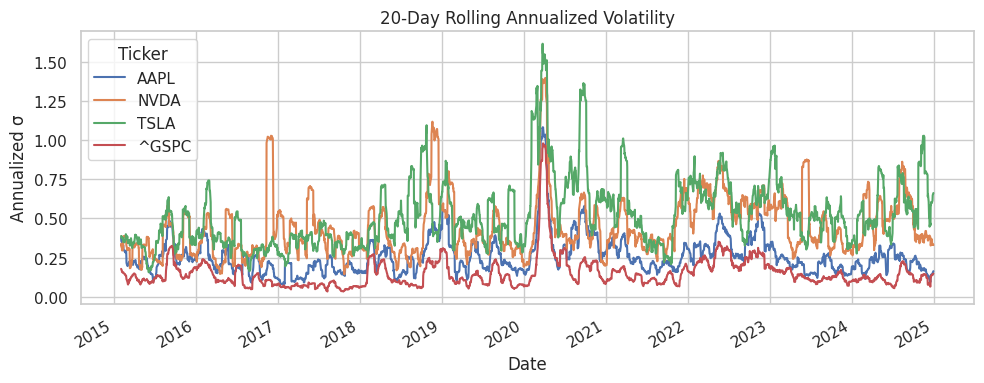

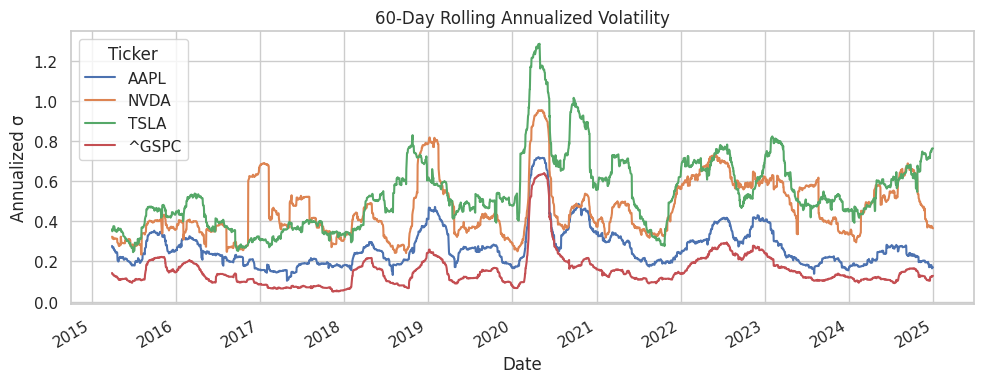

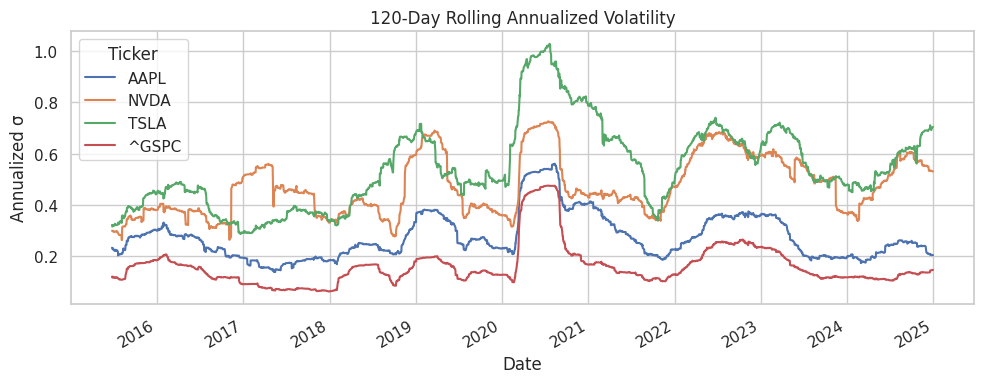

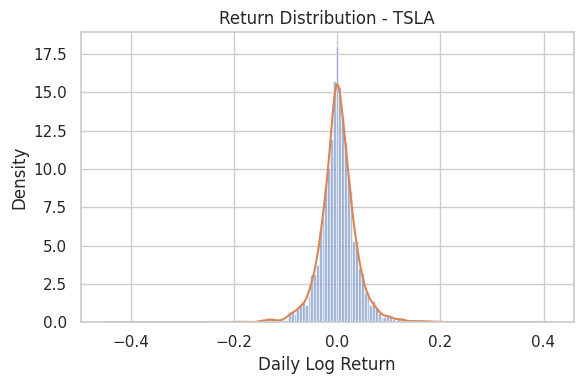

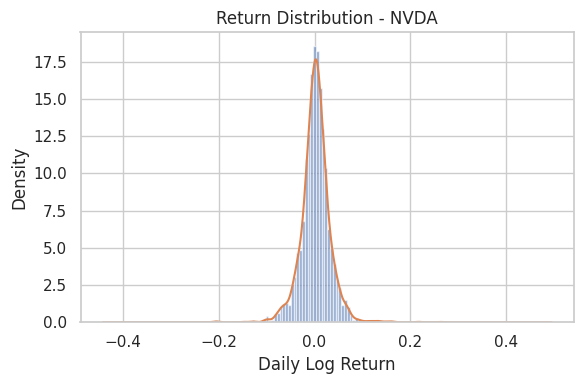

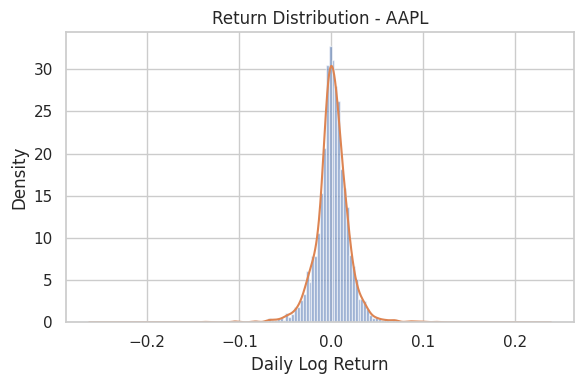

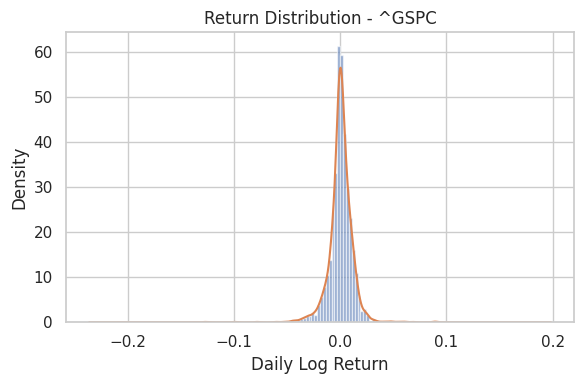


==== |z|>3 極端值次數 ====


,|z|>3 次數
TSLA,40
NVDA,29
AAPL,40
^GSPC,36



==== Beta (vs 市場) ====


,Beta vs ^GSPC
TSLA,1.502938
NVDA,1.734515
AAPL,1.190348


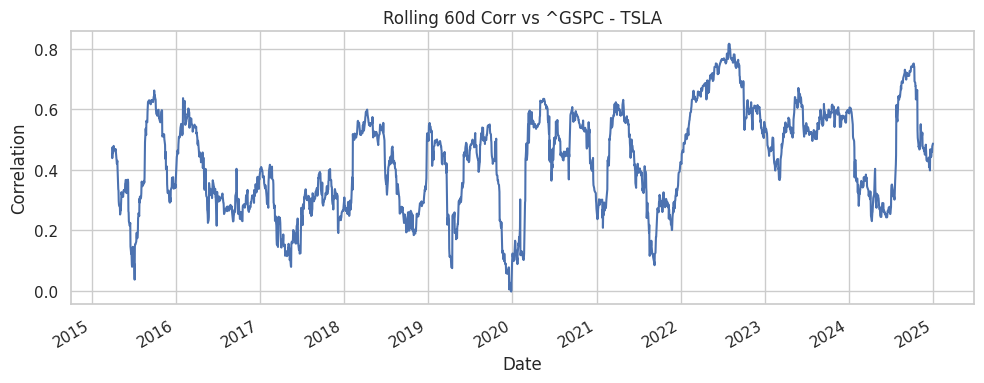

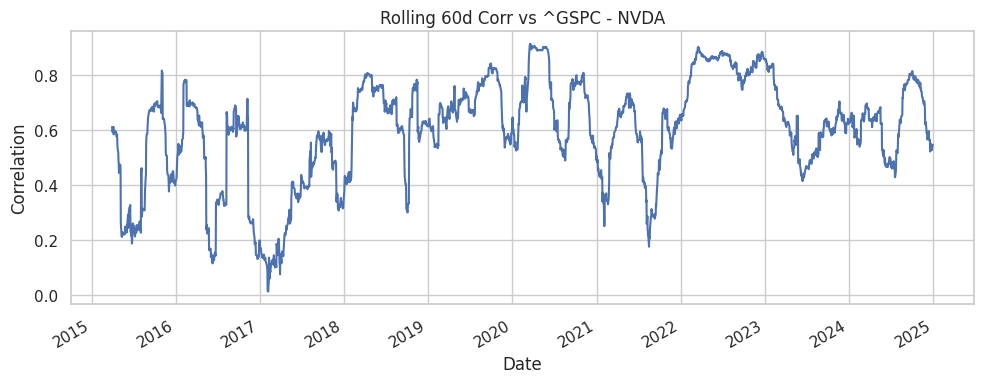

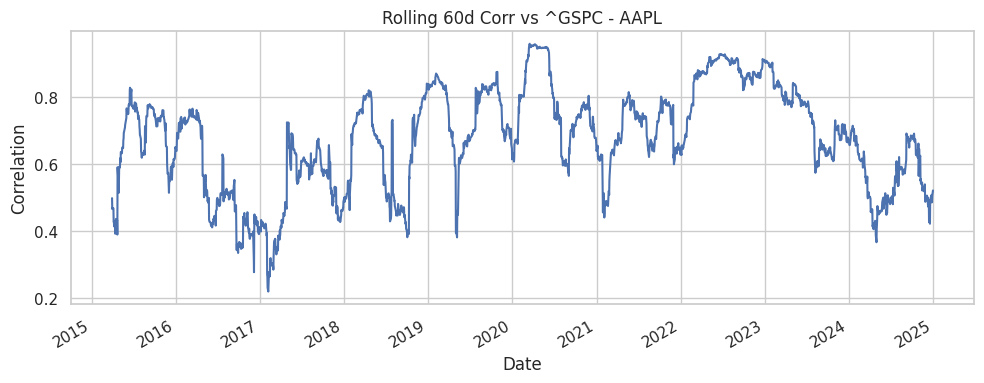


==== 風險指標（日對數報酬）====


,MaxDD,VaR(95%),CVaR(95%)
TSLA,-0.736322,-0.052755,-0.083122
NVDA,-0.663351,-0.045564,-0.067512
AAPL,-0.385159,-0.027367,-0.041708
^GSPC,-0.339250,-0.017051,-0.027860


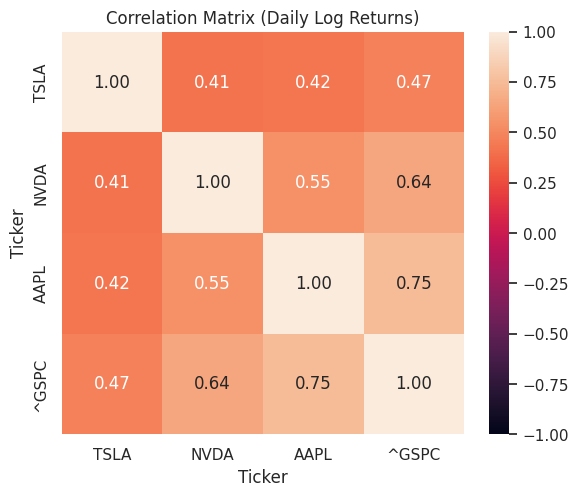

In [ ]:
# ============== 安裝/匯入 ==============
!pip -q install yfinance pandas numpy matplotlib seaborn scipy

import os, math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera
plt.close('all')
sns.set(style="whitegrid")

# ============== 參數設定 ==============
TICKERS = ["TSLA", "NVDA", "AAPL", "^GSPC"]  # 最後一檔作市場基準
START_DATE = "2015-01-01"
END_DATE   = "2024-12-31"
ANNUALIZATION_FACTOR = 252
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============== 下載價格資料 ==============
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    adj = raw["Adj Close"].copy()
else:
    adj = raw.copy()
adj = adj.dropna(how="all").sort_index()

# ============== 對數報酬 ==============
logret = np.log(adj/adj.shift(1)).replace([np.inf, -np.inf], np.nan).dropna(how="all")
sp = logret[TICKERS[-1]].dropna()  # 市場：GSPC

# ===== 1) 基本統計 =====
desc = logret.describe().T
desc["Skew"]     = logret.skew()
desc["Kurtosis"] = logret.kurtosis()
desc["JB_pvalue"] = logret.apply(lambda x: jarque_bera(x.dropna())[1] if x.dropna().size>10 else np.nan)
desc.to_csv(f"{OUT_DIR}/01_desc_stats.csv")
print("==== 基本統計 ====")
display(desc)

# ===== 2) 滾動年化波動 =====
def rolling_vol(r, window):
    return r.rolling(window).std() * math.sqrt(ANNUALIZATION_FACTOR)

for w in [20, 60, 120]:
    vol = rolling_vol(logret, w)
    ax = vol.plot(figsize=(10,4), title=f"{w}-Day Rolling Annualized Volatility")
    ax.set_xlabel("Date"); ax.set_ylabel("Annualized σ")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/vol_{w}d.png", dpi=160)
    plt.show()

# ===== 3) 報酬分布 & 極端值 =====
extreme_counts = {}
for t in TICKERS:
    if t not in logret:
        continue
    ser = logret[t].dropna()
    z = (ser - ser.mean())/ser.std(ddof=0)
    extreme_counts[t] = int(z.abs().gt(3).sum())

    fig, ax = plt.subplots(figsize=(6,4))
    ser.hist(bins=80, density=True, alpha=0.6, ax=ax)
    ser.plot(kind="kde", ax=ax)
    ax.set_title(f"Return Distribution - {t}")
    ax.set_xlabel("Daily Log Return"); ax.set_ylabel("Density")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/dist_{t}.png", dpi=160)
    plt.show()

extreme_df = pd.Series(extreme_counts, name="|z|>3 次數").to_frame()
extreme_df.to_csv(f"{OUT_DIR}/02_extremes.csv")
print("\n==== |z|>3 極端值次數 ====")
display(extreme_df)

# ===== 4) Beta 與滾動相關 =====
beta = {}
for t in [x for x in TICKERS if x != TICKERS[-1] and x in logret.columns]:
    df = pd.concat([logret[t], sp], axis=1, join="inner").dropna()
    df.columns = [t, "MKT"]
    if not df.empty and df["MKT"].std() > 0:
        slope, _ = np.polyfit(df["MKT"].values, df[t].values, 1)
        beta[t] = slope

beta_df = pd.Series(beta, name="Beta vs " + TICKERS[-1]).to_frame()
beta_df.to_csv(f"{OUT_DIR}/03_beta.csv")
print("\n==== Beta (vs 市場) ====")
display(beta_df)

for t in [x for x in TICKERS if x != TICKERS[-1] and x in logret.columns]:
    r = logret[t].rolling(60).corr(sp)
    ax = r.plot(figsize=(10,4), title=f"Rolling 60d Corr vs {TICKERS[-1]} - {t}")
    ax.set_xlabel("Date"); ax.set_ylabel("Correlation")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/corr60_{t}.png", dpi=160)
    plt.show()

# ===== 5) 風險指標 =====
def max_drawdown(logret_series):
    ser = logret_series.dropna()
    if ser.empty: return np.nan
    wealth = np.exp(ser.cumsum())
    dd = wealth/wealth.cummax() - 1
    return dd.min()

def var_95(x):
    x = pd.Series(x).dropna()
    return np.percentile(x, 5) if len(x) else np.nan

def cvar_95(x):
    x = pd.Series(x).dropna()
    if len(x)==0: return np.nan
    cut = np.percentile(x, 5)
    return x[x<=cut].mean() if (x<=cut).any() else np.nan

risk = {}
for t in TICKERS:
    if t in logret.columns:
        risk[t] = {"MaxDD": max_drawdown(logret[t]),
                   "VaR(95%)": var_95(logret[t]),
                   "CVaR(95%)": cvar_95(logret[t])}
risk_df = pd.DataFrame(risk).T
risk_df.to_csv(f"{OUT_DIR}/04_risk.csv")
print("\n==== 風險指標（日對數報酬）====")
display(risk_df)

# ===== 6) 相關矩陣 Heatmap =====
corr = logret.corr().reindex(index=TICKERS, columns=TICKERS)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, square=True, cbar=True)
plt.title("Correlation Matrix (Daily Log Returns)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_corr_heatmap.png", dpi=160)
plt.show()
corr.to_csv(f"{OUT_DIR}/05_corr_matrix.csv")
